In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("food_delivery_orders.csv")

In [4]:
df.head(5)

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


In [10]:
delivery_t = df['delivery_time_min'].dropna()

In [11]:
import matplotlib.pyplot as plt

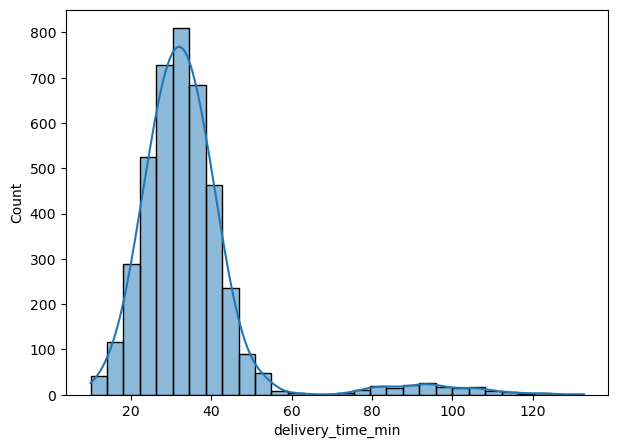

In [15]:
plt.figure(figsize = (7,5))

import seaborn as sns

sns.histplot(delivery_t, kde = True, bins = 30)
plt.show()

The histplot of min delivery time is right skewed which means its mean would be greater than median. Mean is sensitive to changes and tailed data but median is resistent to skewed data so it is better to use.

In [20]:
print("mean: ", delivery_t.mean())
print("median: ", delivery_t.median())
print("skewness: ", delivery_t.skew())

mean:  34.541809523809526
median:  32.5
skewness:  2.8770611473024483


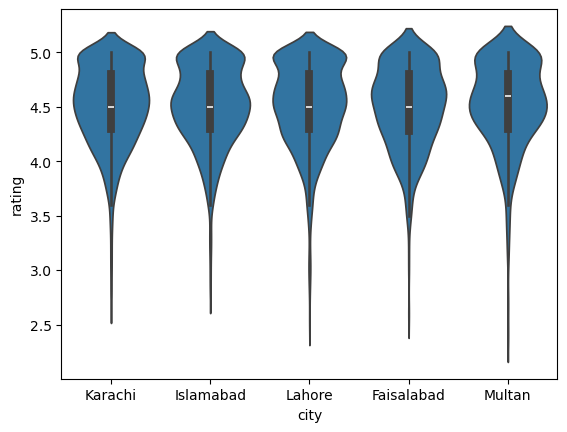

In [21]:
sns.violinplot(data = df, x = 'city', y = 'rating')
plt.show()

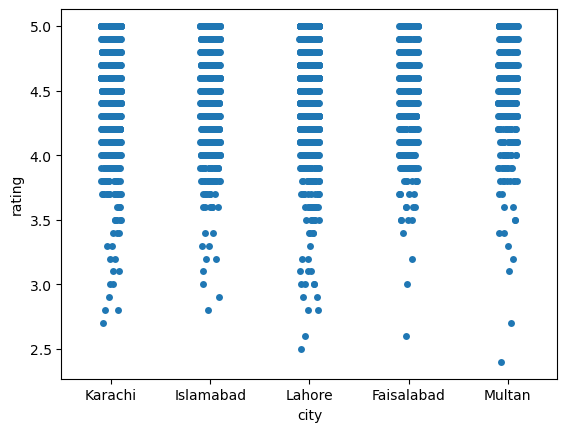

In [23]:
sns.stripplot(data = df, x = 'city', y = 'rating', jitter = True)
plt.show()

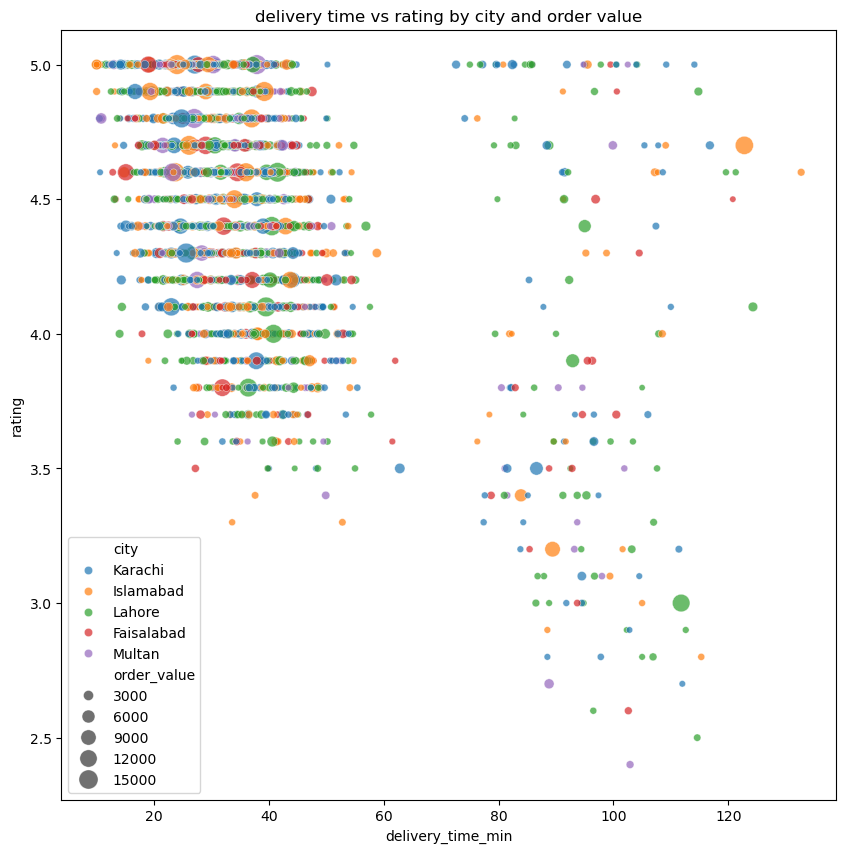

In [34]:
plt.figure(figsize = (10,10))
sns.scatterplot(data = df, x = 'delivery_time_min', y = 'rating', hue = 'city', size = 'order_value', sizes=(20, 200), alpha=0.7)
plt.title("delivery time vs rating by city and order value")
plt.show()

higher rating points are clustered around lesser delivery time and high order values are mostly highly rated too. using cities for hue also shows patterns across cities

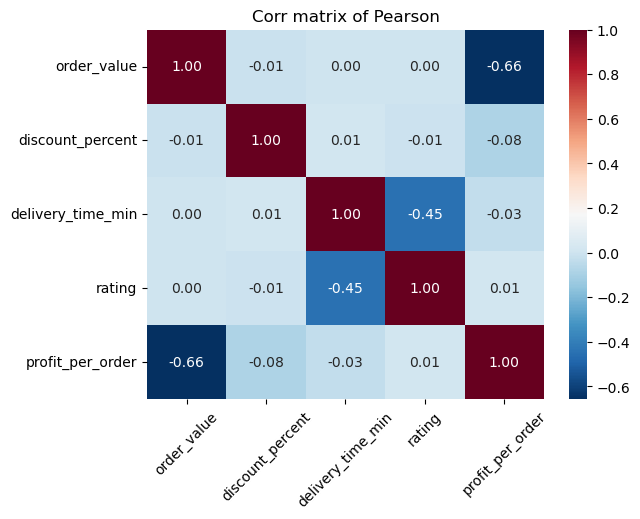

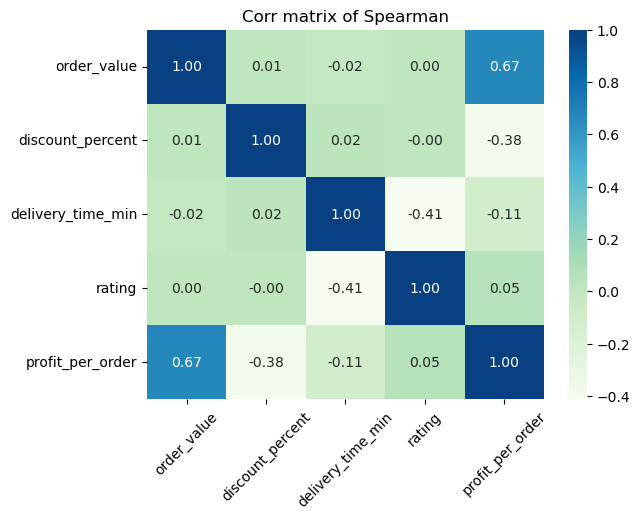

In [57]:
num_cols = df.select_dtypes(include = "number").columns

pearson_mat = df[num_cols].corr(method = "pearson")
spearman_mat = df[num_cols].corr(method = "spearman")

sns.heatmap(pearson_mat, annot = True, cmap = 'RdBu_r', fmt = '.2f')
plt.title("Corr matrix of Pearson")
plt.xticks(rotation=45)
plt.show()

sns.heatmap(spearman_mat, annot = True, cmap = 'GnBu', fmt = '.2f')
plt.title("Corr matrix of Spearman")
plt.xticks(rotation=45)
plt.show()


the two methods have a conflict on the relationship between 'order_value' and 'profit_per_order'. pearson relation shows negative 0.66 and spearman show exact opposite, positive 0.67. 

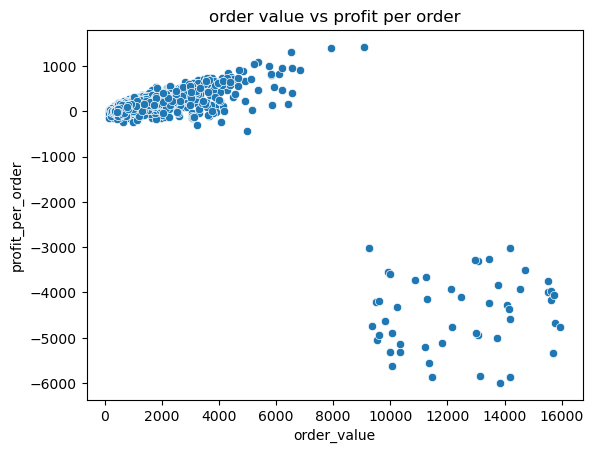

In [50]:
sns.scatterplot(data = df,x = "order_value", y = "profit_per_order")
plt.title("order value vs profit per order")
plt.show()

most of the data above is clustered around low order values while there some outliers at high order values which relate to profit negatively. pearson method is highly sensitive to outliers so the difference in the answers of the 2 methods is likely due to he outliers rather than non-linear relationship. regardless of some outliers, we cannot ignore the possibility that high order values may in fact impact profit negaively because correlation is not causation. plus, there may be some other factors affecting these values.

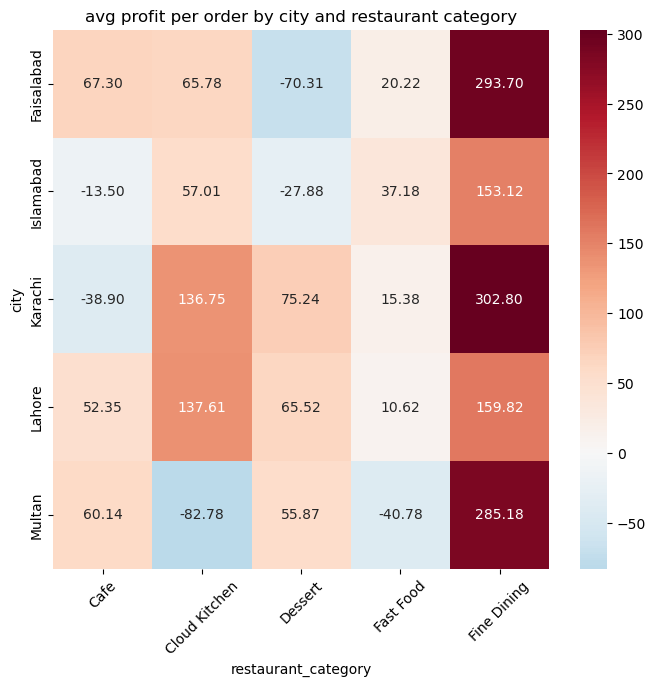

In [62]:
pivot = pd.pivot_table(df, values='profit_per_order', index='city', columns='restaurant_category', aggfunc='mean', margins=True)
pivot = pivot.drop(index = 'All', columns = 'All')
plt.figure(figsize = (8,7))
sns.heatmap(pivot,annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('avg profit per order by city and restaurant category')
plt.xticks(rotation = 45)
plt.show()

In [65]:
comb = pivot.stack().idxmax()
profit = pivot.stack().max()
print('best comb: ', comb, '\navg profit per order:', profit)

best comb:  ('Karachi', 'Fine Dining') 
avg profit per order: 302.8014184397163


to find if most profitable combination or city is also the biggest revenue generator:

In [67]:
revenue = pd.pivot_table(df, values = 'order_value', index = 'city', columns = 'restaurant_category', aggfunc = 'sum')
print('top revenue gen: ', revenue.stack().idxmax())

top revenue gen:  ('Lahore', 'Cloud Kitchen')


thus, top revenue generator and most profitable city+categry combination are different

In [68]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [69]:
monthly_rating = df.set_index("order_date")["rating"].resample("ME").mean()

In [70]:
rolling_rating = monthly_rating.rolling(3).mean()

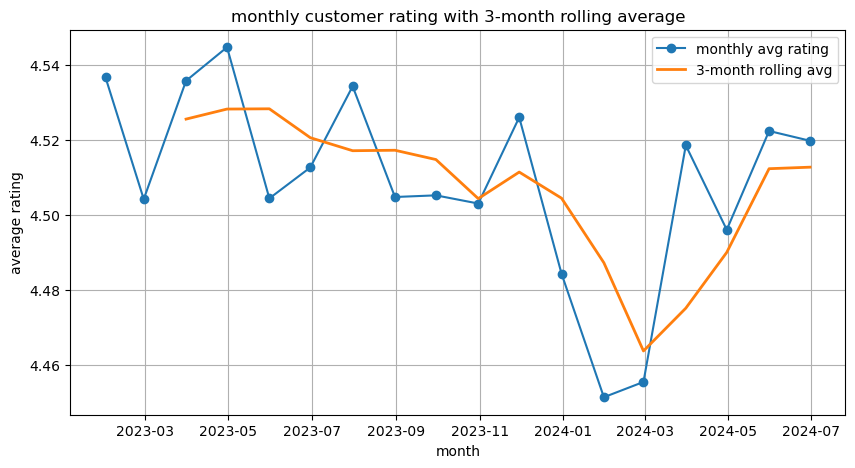

In [78]:
plt.figure(figsize = (10,5))
plt.plot(monthly_rating.index, monthly_rating, marker = 'o', label = 'monthly avg rating')
plt.plot(rolling_rating.index, rolling_rating, linewidth = 2, label = '3-month rolling avg')
plt.xlabel("month")
plt.ylabel("average rating")
plt.title("monthly customer rating with 3-month rolling average")
plt.xlabel("month")
plt.ylabel("average rating")
plt.title("monthly customer rating with 3-month rolling average")
plt.legend()
plt.grid(True)
plt.show()

yes for some months in 2023, 3 month rolling average flattens but overall general rend shows decreasing customer rating and satisfaction.

In [79]:
df["heavy_discount"] = df["discount_percent"] > 20

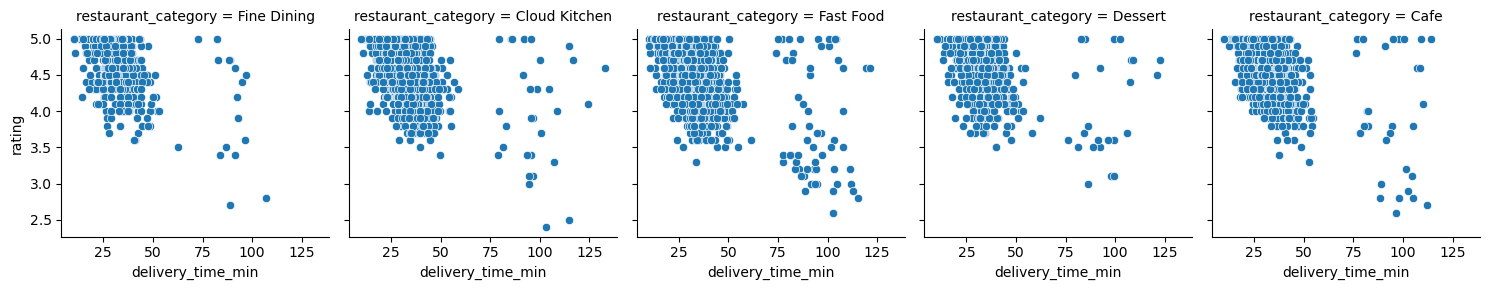

In [84]:
g = sns.FacetGrid(
    df,
    col="restaurant_category"
)

g.map_dataframe(
    sns.scatterplot,
    x="delivery_time_min",
    y="rating"
)

plt.show()

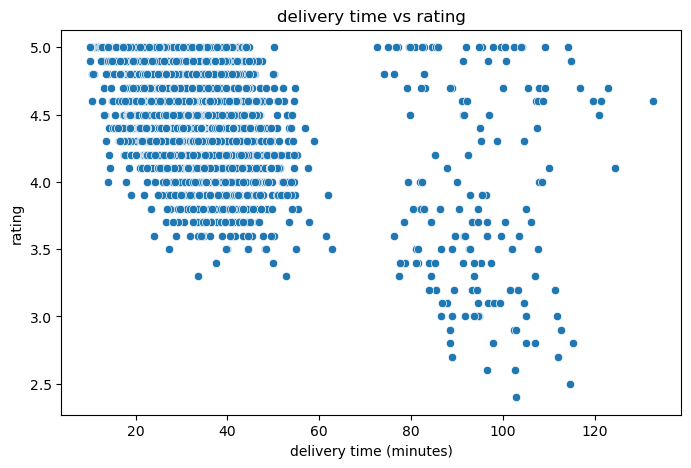

In [85]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="delivery_time_min",
    y="rating"
)

plt.title("delivery time vs rating")
plt.xlabel("delivery time (minutes)")
plt.ylabel("rating")
plt.show()

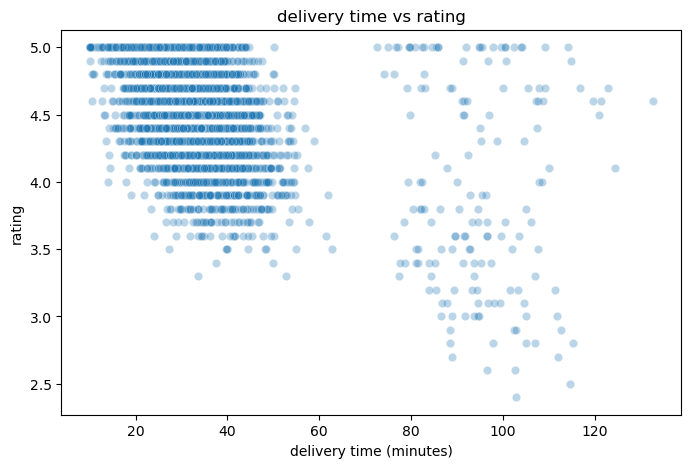

In [86]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="delivery_time_min",
    y="rating",
    alpha=0.3
)

plt.title("delivery time vs rating")
plt.xlabel("delivery time (minutes)")
plt.ylabel("rating")
plt.show()

In [87]:
best_long = df[df["rating"] == df["rating"].max()].sort_values(
    "delivery_time_min",
    ascending=False
)

print(best_long.head())

     order_date     city restaurant_category          cuisine  order_value  \
3723 2024-04-30  Karachi                Cafe           Bakery        507.0   
1704 2023-08-12  Karachi                Cafe  Coffee & Snacks        528.0   
2940 2024-01-21   Lahore           Fast Food       Sandwiches        704.0   
3851 2024-05-20  Karachi           Fast Food       Sandwiches        510.0   
3636 2024-04-16   Multan             Dessert        Ice Cream        369.0   

      discount_percent  delivery_time_min  rating  profit_per_order  \
3723              17.7              114.1     5.0            -116.0   
1704               1.8              109.2     5.0             -28.0   
2940               4.4              104.1     5.0              70.0   
3851              23.9              104.0     5.0            -104.0   
3636              12.4              102.5     5.0             -50.0   

      heavy_discount  
3723           False  
1704           False  
2940           False  
3851        

In [88]:
worst_fast = df[df["rating"] == df["rating"].min()].sort_values(
    "delivery_time_min"
)

print(worst_fast.head())

    order_date    city restaurant_category cuisine  order_value  \
101 2023-01-14  Multan       Cloud Kitchen  Indian       1197.0   

     discount_percent  delivery_time_min  rating  profit_per_order  \
101               1.8              102.9     2.4             171.0   

     heavy_discount  
101           False  


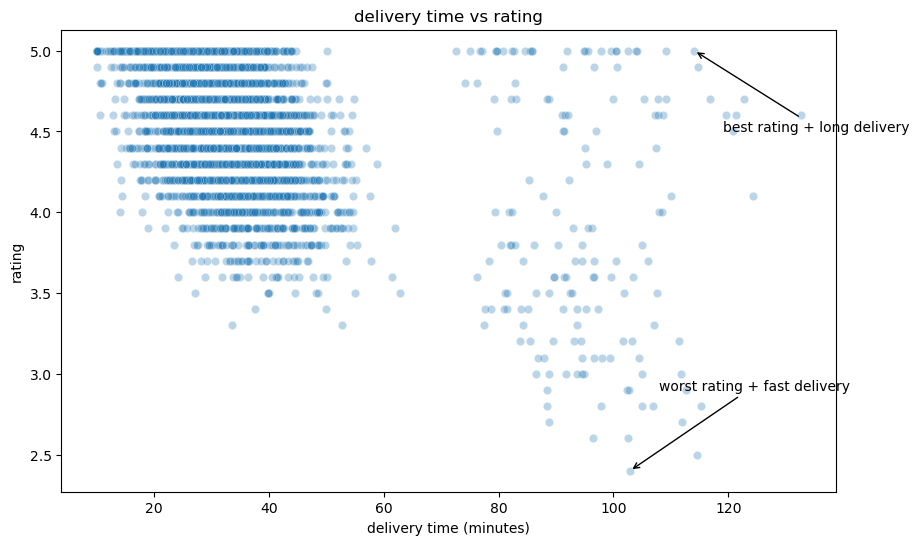

In [89]:
best_long = df[df["rating"] == df["rating"].max()].sort_values(
    "delivery_time_min",
    ascending=False
).iloc[0]

worst_fast = df[df["rating"] == df["rating"].min()].sort_values(
    "delivery_time_min"
).iloc[0]

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="delivery_time_min",
    y="rating",
    alpha=0.3
)

plt.annotate(
    "best rating + long delivery",
    xy=(best_long["delivery_time_min"], best_long["rating"]),
    xytext=(best_long["delivery_time_min"] + 5, best_long["rating"] - 0.5),
    arrowprops=dict(arrowstyle="->")
)

plt.annotate(
    "worst rating + fast delivery",
    xy=(worst_fast["delivery_time_min"], worst_fast["rating"]),
    xytext=(worst_fast["delivery_time_min"] + 5, worst_fast["rating"] + 0.5),
    arrowprops=dict(arrowstyle="->")
)

plt.title("delivery time vs rating")
plt.xlabel("delivery time (minutes)")
plt.ylabel("rating")

plt.show()